**الاسم : دانا حسن بافقيه**


**شعبه: 2**

#**Import Libraries**

In [ ]:
# For the dataset
import pandas as pd
import numpy as np

# For preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

#Supervised (SVM)
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

#Unsupervised (K-Means & Hierarchical Clustering)
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, silhouette_score, roc_curve
    )

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

#**Step 1: Data Preprocessing**

##Load the dataset

###First Dataset

In [ ]:
# Read the data (Breast Cancer Wisconsin (Diagnostic) Dataset)
Cancer  = pd.read_csv('/content/wdbc[1].data',
                      header = None,      # The data without header
                      delimiter=' *, *',
                      engine='python')

In [ ]:
# Add header to the dataset
Cancer.columns = ['ID','Diagnosis' , 'radius1', 'texture1', 'perimeter1', 'area1',
                    'smoothness1', 'compactness1', 'concavity1',
                    'concave_points1', 'symmetry1', 'fractal_dimension1',
                  'radius2','texture2', 'perimeter2',
                 'area2', 'smoothness2', 'compactness2', 'concavity2',
                 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3',
                 'texture3', 'perimeter3', 'area3', 'smoothness3',
                 'compactness3', 'concavity3', 'concave_points3','symmetry3',
                 'fractal_dimension3']

In [ ]:
# Print the first 5 rows
Cancer.head()

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


###Second dataset

In [ ]:
# Read the data (Adult Income Dataset (Census Income))
adult = pd.read_csv('/content/adult[1].data',
                    header = None,              # The data without header
                    delimiter=' *, *', engine='python')

In [ ]:
# Add header to the dataset
adult.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
                    'marital_status', 'occupation', 'relationship',
                    'race', 'sex', 'capital_gain', 'capital_loss',
                    'hours_per_week', 'native_country', 'income']

In [ ]:
# Print the first 5 rows
adult.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


##Handling Missing Value

###Frist Dataset

In [ ]:
# Show information about the data (columns, type, null count)
Cancer.isnull().sum()

,0
ID,0
Diagnosis,0
radius1,0
texture1,0
perimeter1,0
area1,0
smoothness1,0
compactness1,0
concavity1,0
concave_points1,0


As we can see, there are no missing value.

###Second Dataset

In [ ]:
# Check for missing vlues value
adult.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


Even though it shows no missing value (null), but the data source indicates that some value are missing!

This means they may not be null, but the column contains invalid or missing values.

In [ ]:
# Check the unique values for columns that may contain missing or invalid values
for col in ['workclass', 'occupation', 'native_country']:
    print(f"Column: {col}")
    print(adult[col].unique())
    print("\n")

Column: workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']


Column: occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']


Column: native_country
['United-States' 'Cuba' 'Jamaica' 'India' '?' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' 'Canada' 'Germany' 'Iran'
 'Philippines' 'Italy' 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador'
 'Laos' 'Taiwan' 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador'
 'France' 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 'Scotland' 'Trinadad&Tobago' 'Greece'
 'Nicaragua' 'Vietnam' 'Hong' 'Ireland' 'Hungary' 'Holand-Netherlands']




We can observe that some entries contain `?` value

In [ ]:
# Replace the '?' with the mode because these are categorical features
for col in ['workclass', 'occupation', 'native_country']:
  adult[col] = adult[col].replace('?', adult[col].mode()[0])

In [ ]:
# Check again
for col in ['workclass', 'occupation', 'native_country']:
    print(f"Column: {col}")
    print(adult[col].unique())
    print("\n")

Column: workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']


Column: occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']


Column: native_country
['United-States' 'Cuba' 'Jamaica' 'India' 'Mexico' 'South' 'Puerto-Rico'
 'Honduras' 'England' 'Canada' 'Germany' 'Iran' 'Philippines' 'Italy'
 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador' 'Laos' 'Taiwan'
 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador' 'France'
 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 'Scotland' 'Trinadad&Tobago' 'Greece'
 'Nicaragua' 'Vietnam' 'Hong' 'Ireland' 'Hungary' 'Holand-Netherlands']




We can see that there are **no** more `?` values remaining

##Data Encoding

I apply encoding to convert the categorical columns into numbers. I also apply it to the target column in both datasets to make it easier to work with

###First Dataset

In [ ]:
# Encode the 'Diagnosis' column with LabelEncoder because it's binary
le = LabelEncoder()
Cancer['Diagnosis'] = le.fit_transform(Cancer['Diagnosis'])

print(Cancer.head())

         ID  Diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0    842302          1    17.99     10.38      122.80  1001.0      0.11840   
1    842517          1    20.57     17.77      132.90  1326.0      0.08474   
2  84300903          1    19.69     21.25      130.00  1203.0      0.10960   
3  84348301          1    11.42     20.38       77.58   386.1      0.14250   
4  84358402          1    20.29     14.34      135.10  1297.0      0.10030   

   compactness1  concavity1  concave_points1  ...  radius3  texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3  \
0      184.60  20

###Second Dataset

In [ ]:
# Encode the 'sex' and 'income' columns with LabelEncoder because it's binary
le = LabelEncoder()
for col in ['sex', 'income']:
    adult[col] = le.fit_transform(adult[col])

# Encode remaining categorical features with One-Hot because there is no ordering in the data
adultE = pd.get_dummies( adult, columns=['workclass', 'education', 'marital_status', 'occupation',
             'relationship', 'race', 'native_country'], dtype=int)

print(adultE.head())

   age  fnlwgt  education_num  sex  capital_gain  capital_loss  \
0   39   77516             13    1          2174             0   
1   50   83311             13    1             0             0   
2   38  215646              9    1             0             0   
3   53  234721              7    1             0             0   
4   28  338409             13    0             0             0   

   hours_per_week  income  workclass_Federal-gov  workclass_Local-gov  ...  \
0              40       0                      0                    0  ...   
1              13       0                      0                    0  ...   
2              40       0                      0                    0  ...   
3              40       0                      0                    0  ...   
4              40       0                      0                    0  ...   

   native_country_Portugal  native_country_Puerto-Rico  \
0                        0                           0   
1                 

##Data Standardization

I apply standardization to numerical features so all columns have the same scale. If it is not used, features with large values can dominate the calculations, causing bias and lower accuracy for SVM and clustering.

Because Standardization
 is applied only to numerical features, i split the data into features and target before applying Standardization.

###First Dataset

In [ ]:
# Split features and target
CancerX = Cancer.drop(['Diagnosis'], axis=1)  # Feature
Cancery = Cancer['Diagnosis']                 # Target

In [ ]:
# Applying Standardization to scale features
scaler = StandardScaler()
CancerX_stand = scaler.fit_transform(CancerX)

###Second Dataset

In [ ]:
# Split features and target
adultX = adultE.drop(['income'], axis=1)   # Feature
adulty = adultE['income']                  # Target

In [ ]:
# Applying Standardization to scale features
scaler = StandardScaler()
adultX_stand = scaler.fit_transform(adultX)

##Split the Dataset *(for the supervised SVM ONLY)*

###First Dataset

In [ ]:
#Split the dataset into training and testing sets (70% train, 30% test).
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    CancerX_stand, Cancery, test_size=0.3, random_state=42
    )

###Second Dataset

In [ ]:
#Split the dataset into training and testing sets (70% train, 30% test).
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    adultX_stand, adulty, test_size=0.3, random_state=42
    )

#Step 2: Model Building

##Supervised Model: SVM

I used two Kernel:
* **Linear Kernel:**
is used when the data is *linearly separable*. It separates the data using a single straight line. It has one hyperparameter **C** which balances between maximizing the margin and penalizing misclassified points. A larger C means a stricter penalty for errors, while a smaller C allows a wider margin and more tolerance for misclassification.


* **RBF Kernel:**
is used for *non-linear data* It transforms the data into a higher-dimensional space to create a non-linear decision boundary. It has two hyperparameters: **C** (same as in Linear Kernel) and **gamma**, which determines how far the influence of each training point reaches.

I used **GridSearchCV** on both datasets to find the **best hyperparameters** and show the best result

###First Dataset

In [ ]:
#Linear Kernel SVM
linear_paramsC = {
    "C": [0.1, 1, 10, 50, 100]
}

linear_svmC = SVC(kernel="linear", probability=True)

grid_linearC = GridSearchCV(linear_svmC, linear_paramsC, cv=5, scoring="accuracy")
grid_linearC.fit(Xc_train, yc_train)

print("Best Linear SVM params:", grid_linearC.best_params_)
print("Best Linear SVM score:", grid_linearC.best_score_)

Best Linear SVM params: {'C': 0.1}
Best Linear SVM score: 0.9748417721518987


In [ ]:
#RBF Kernel SVM
rbf_paramsC = {
   "C": [0.1, 1, 10, 50, 100],
   "gamma": ["scale", 0.1, 0.01, 0.001]
}

rbf_svmC = SVC(kernel="rbf", probability=True)

grid_rbfC = GridSearchCV(rbf_svmC, rbf_paramsC, cv=5, scoring="accuracy")
grid_rbfC.fit(Xc_train, yc_train)

print("Best RBF params:", grid_rbfC.best_params_)
print("Best RBF score:", grid_rbfC.best_score_)


Best RBF params: {'C': 50, 'gamma': 0.001}
Best RBF score: 0.9723101265822784


###Second Dataset

In [ ]:
# Take a random sample (20%) from the training data to speed up training
sample_frac = 0.2
Xa_train_df = pd.DataFrame(Xa_train)  # Convert training features to DataFrame
Xa_train_df['target'] = ya_train.values  # Temporarily add the target column

# Sample the data
Xa_train_sample = Xa_train_df.sample(frac=sample_frac, random_state=42)

# Separate features and target again
ya_train_sample = Xa_train_sample['target']
Xa_train_sample = Xa_train_sample.drop('target', axis=1)


In [ ]:
# Linear SVM
linear_svmA = SVC(kernel='linear', probability=True)

# Define hyperparameters for GridSearchCV
linear_paramsA = {"C":  [0.1, 1, 10, 50]}

# GridSearchCV for hyperparameter tuning
grid_linearA = GridSearchCV(linear_svmA, linear_paramsA, cv=3, scoring='accuracy')
grid_linearA.fit(Xa_train_sample, ya_train_sample)

print("Best Linear SVM best params:", grid_linearA.best_params_)
print("Best Linear SVM score:", grid_linearA.best_score_)

Best Linear SVM best params: {'C': 1}
Best Linear SVM score: 0.840503476433018


In [ ]:
# RBF SVM
rbf_svmA = SVC(kernel='rbf', probability=True)

# Hyperparameters for GridSearchCV
rbf_paramsA = {
   "C": [0.1, 1, 10, 50, 100],
   "gamma": ["scale", 0.1, 0.01, 0.001]
}

# GridSearchCV for hyperparameter tuning
grid_rbfA = GridSearchCV(rbf_svmA, rbf_paramsA, cv=3, scoring='accuracy')
grid_rbfA.fit(Xa_train_sample, ya_train_sample)

print("Best Linear SVM best params:", grid_rbfA.best_params_)
print("Best Linear SVM score:", grid_rbfA.best_score_)

Best Linear SVM best params: {'C': 100, 'gamma': 0.001}
Best Linear SVM score: 0.8418196990171282


Larger **C** and **gamma** make the model stricter and the margin smaller, while smaller values allow a wider margin and smoother decision boundary.

##Unsupervised Models: K-Means & Hierarchical Clustering

###First Dataset

In [ ]:
# K-Means Clustering
kmeansC = KMeans(n_clusters=2, random_state=42) #n_clusters=2 because there are two classes in the dataset.
kmeansC.fit(CancerX_stand) #only features, no labels

kmeans_labelsC = kmeansC.fit_predict(CancerX_stand)

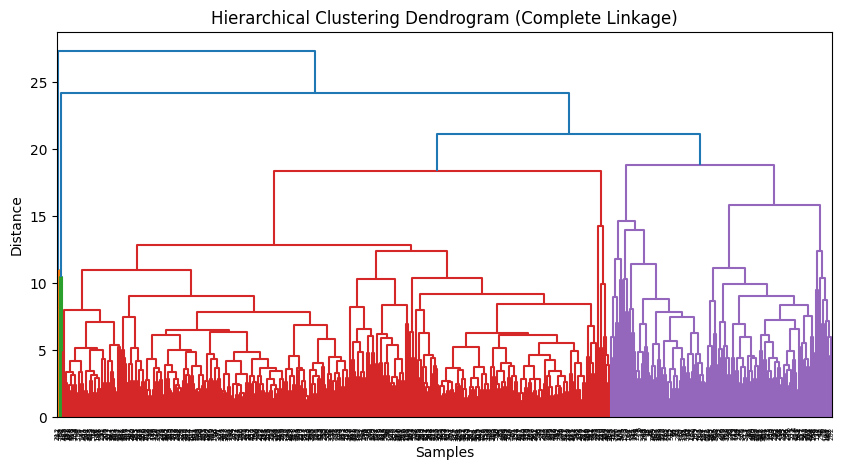

In [ ]:
# Compute linkage (Hierarchical Clustering)
completeC = linkage(CancerX_stand, method='complete')

#Plots dendrogram (Agglomerative)
plt.figure(figsize=(10, 5))
dendrogram(completeC)
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

#cut the dendrogram to get a specific number of clusters using fcluster
clustersC = fcluster(completeC, t=2, criterion='maxclust')  #t=2: Specifies the desired number of clusters.


There is a large vertical distance between 20 and 25 where no merges happen. So when we cut the dendrogram at this height, we get 2 clear clusters.

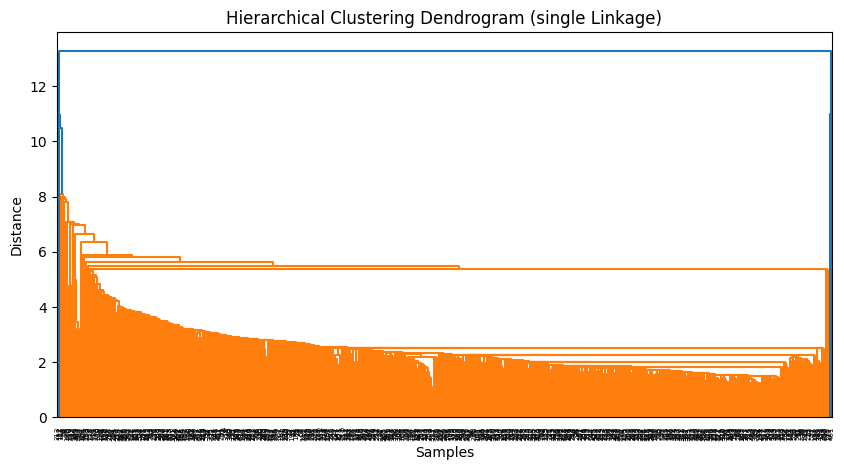

In [ ]:
# Compute linkage (Hierarchical Clustering)
singleC = linkage(CancerX_stand, method='single')

#Plots dendrogram (Agglomerative)
plt.figure(figsize=(10, 5))
dendrogram(singleC)
plt.title("Hierarchical Clustering Dendrogram (single Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

#cut the dendrogram to get a specific number of clusters using fcluster
clustersC2 = fcluster(singleC, t=2, criterion='maxclust')  #t=2: Specifies the desired number of clusters.


###Second Dataset

In [ ]:
kmeansA = KMeans(n_clusters=2, random_state=42)
kmeansA.fit(adultX_stand) #only features, no labels

labels_kmeansA = kmeansA.fit_predict(adultX_stand)

In [ ]:
# Compute linkage (Hierarchical Clustering)
completeA = linkage(adultX_stand, method='complete')

#cut the dendrogram to get a specific number of clusters using fcluster
clustersA = fcluster(completeA, t=2, criterion='maxclust')  #t=2: Specifies the desired number of clusters.


In [ ]:
# Compute linkage (Hierarchical Clustering)
singleA = linkage(adultX_stand, method='single')

#cut the dendrogram to get a specific number of clusters using fcluster
clustersA2 = fcluster(singleA, t=2, criterion='maxclust')  #t=2: Specifies the desired number of clusters.


#Model Evaluation and Visualization

##SVM Evaluation (Supervised)

###First Dataset

In [ ]:
#Predict class labels
print("\nSVM With Linear Kernel:")
y_pred_linearC = grid_linearC.predict(Xc_test)
print(y_pred_linearC)

print('\n')

print("\nSVM With RBF Kernel:")
y_pred_rbfC = grid_rbfC.predict(Xc_test)
print(y_pred_rbfC)


SVM With Linear Kernel:
[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]



SVM With RBF Kernel:
[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [ ]:
print("\nSVM With Linear Kernel:")
# Model Evaluation Metrics
print("\nAccuracy:", accuracy_score(yc_test, y_pred_linearC))
print("Precision:", precision_score(yc_test, y_pred_linearC))
print("Recall:", recall_score(yc_test, y_pred_linearC))
print("F1 Score:", f1_score(yc_test, y_pred_linearC))
print("AUC - ROC Score:", roc_auc_score(yc_test, grid_linearC.predict_proba(Xc_test)[:,1]))

print("\n-----------------------------------------------")

print("\nSVM With RBF Kernel")
print("\nAccuracy:", accuracy_score(yc_test, y_pred_rbfC))
print("Precision:", precision_score(yc_test, y_pred_rbfC))
print("Recall:", recall_score(yc_test, y_pred_rbfC))
print("F1 Score:", f1_score(yc_test, y_pred_rbfC))
print("AUC - ROC Score:", roc_auc_score(yc_test, grid_rbfC.predict_proba(Xc_test)[:,1]))


SVM With Linear Kernel:

Accuracy: 0.9824561403508771
Precision: 0.9838709677419355
Recall: 0.9682539682539683
F1 Score: 0.976
AUC - ROC Score: 0.9976484420928865

-----------------------------------------------

SVM With RBF Kernel

Accuracy: 0.9824561403508771
Precision: 0.9838709677419355
Recall: 0.9682539682539683
F1 Score: 0.976
AUC - ROC Score: 0.9979423868312758


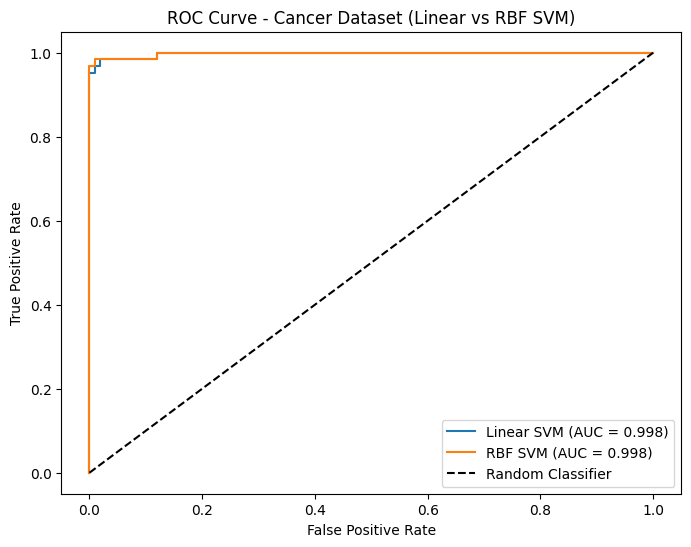

In [ ]:
# Compute ROC curves
auc_linear = roc_auc_score(yc_test, grid_linearC.predict_proba(Xc_test)[:,1])
auc_rbf    = roc_auc_score(yc_test, grid_rbfC.predict_proba(Xc_test)[:,1])
fpr_linear, tpr_linear, _ = roc_curve(yc_test, grid_linearC.predict_proba(Xc_test)[:,1])
fpr_rbf, tpr_rbf, _ = roc_curve(yc_test, grid_rbfC.predict_proba(Xc_test)[:,1])

# Plot ROC curves overlayed
plt.figure(figsize=(8,6))
plt.plot(fpr_linear, tpr_linear, label=f"Linear SVM (AUC = {auc_linear:.3f})")
plt.plot(fpr_rbf, tpr_rbf, label=f"RBF SVM (AUC = {auc_rbf:.3f})")
plt.plot([0,1], [0,1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cancer Dataset (Linear vs RBF SVM)")
plt.legend()
plt.show()

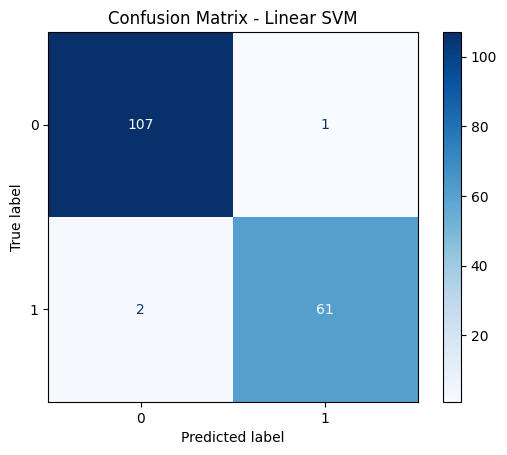

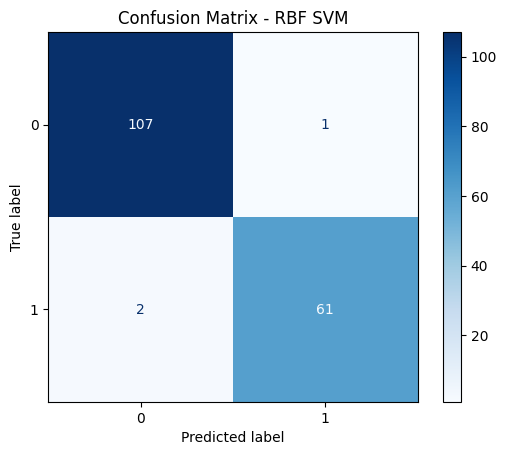

In [ ]:
# Linear SVM
cm_linear = confusion_matrix(yc_test, y_pred_linearC)
disp_linear = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=grid_linearC.classes_)
disp_linear.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Linear SVM")
plt.show()

# RBF SVM
cm_rbf = confusion_matrix(yc_test, y_pred_rbfC)
disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=grid_rbfC.classes_)
disp_rbf.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - RBF SVM")
plt.show()

###Second Dataset

In [ ]:
print("\nSVM With Linear Kernel:")
y_pred_linearA = grid_linearA.predict(Xa_test)
print(y_pred_linearA)

print('\n')

print("\nSVM With RBF Kernel:")
y_pred_rbfA = grid_rbfA.predict(Xa_test)
print(y_pred_rbfA)


SVM With Linear Kernel:
[0 0 1 ... 0 0 1]



SVM With RBF Kernel:
[0 0 1 ... 0 0 1]


In [ ]:
print("\nSVM With Linear Kernel:")
# Model Evaluation Metrics
print("\nAccuracy:", accuracy_score(ya_test, y_pred_linearA))
print("Precision:", precision_score(ya_test, y_pred_linearA))
print("Recall:", recall_score(ya_test, y_pred_linearA))
print("F1 Score:", f1_score(ya_test, y_pred_linearA))
print("AUC - ROC Score:", roc_auc_score(ya_test, grid_linearA.predict_proba(Xa_test)[:,1]))

print("\n-----------------------------------------------")

print("\nSVM With RBF Kernel")
print("\nAccuracy:", accuracy_score(ya_test, y_pred_rbfA))
print("Precision:", precision_score(ya_test, y_pred_rbfA))
print("Recall:", recall_score(ya_test, y_pred_rbfA))
print("F1 Score:", f1_score(ya_test, y_pred_rbfA))
print("AUC - ROC Score:", roc_auc_score(ya_test, grid_rbfA.predict_proba(Xa_test)[:,1]))


SVM With Linear Kernel:

Accuracy: 0.846043607329307
Precision: 0.7113778705636743
Recall: 0.5890233362143474
F1 Score: 0.6444444444444445
AUC - ROC Score: 0.8952900346475279

-----------------------------------------------

SVM With RBF Kernel

Accuracy: 0.8444057733647251
Precision: 0.7122994652406417
Recall: 0.5756266205704408
F1 Score: 0.6367112810707457
AUC - ROC Score: 0.8879368982549866


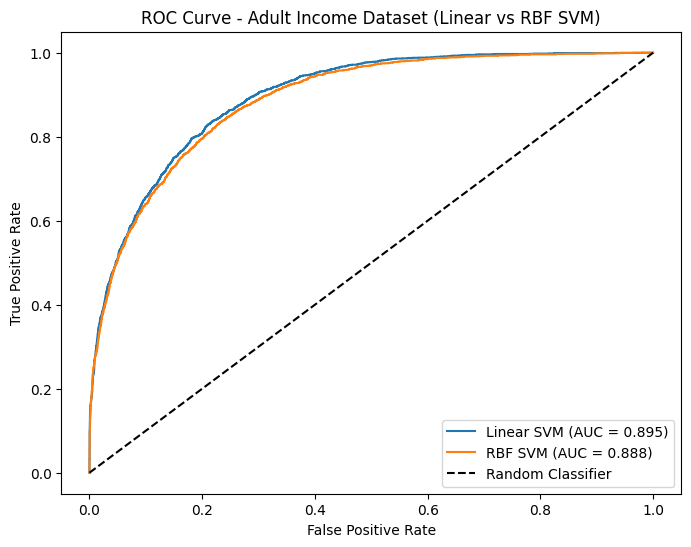

In [ ]:
# Compute ROC curves
auc_linearA = roc_auc_score(ya_test, grid_linearA.predict_proba(Xa_test)[:,1])
auc_rbfA    = roc_auc_score(ya_test, grid_rbfA.predict_proba(Xa_test)[:,1])
fpr_linearA, tpr_linearA, _ = roc_curve(ya_test, grid_linearA.predict_proba(Xa_test)[:,1])
fpr_rbfA, tpr_rbfA, _ = roc_curve(ya_test, grid_rbfA.predict_proba(Xa_test)[:,1])

# Plot ROC curves overlayed
plt.figure(figsize=(8,6))
plt.plot(fpr_linearA, tpr_linearA, label=f"Linear SVM (AUC = {auc_linearA:.3f})")
plt.plot(fpr_rbfA, tpr_rbfA, label=f"RBF SVM (AUC = {auc_rbfA:.3f})")
plt.plot([0,1], [0,1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Adult Income Dataset (Linear vs RBF SVM)")
plt.legend()
plt.show()

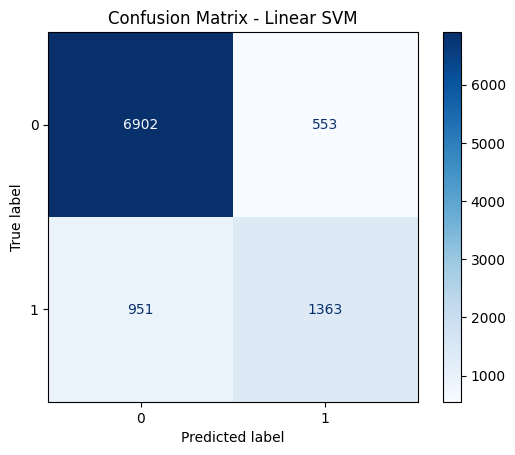

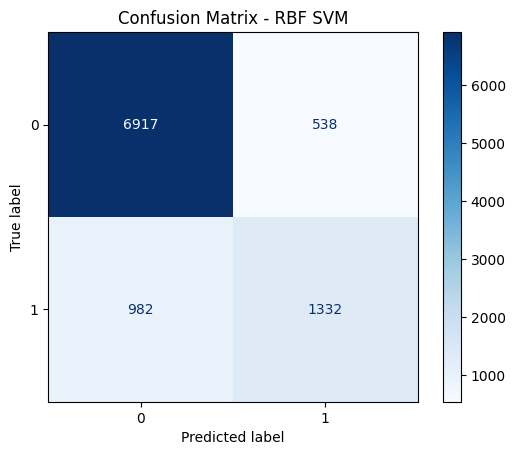

In [ ]:
# Linear SVM
cm_linearA = confusion_matrix(ya_test, y_pred_linearA)
disp_linearA = ConfusionMatrixDisplay(confusion_matrix=cm_linearA, display_labels=grid_linearA.classes_)
disp_linearA.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Linear SVM")
plt.show()

# RBF SVM
cm_rbfA = confusion_matrix(ya_test, y_pred_rbfA)
disp_rbfA = ConfusionMatrixDisplay(confusion_matrix=cm_rbfA, display_labels=grid_rbfA.classes_)
disp_rbfA.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - RBF SVM")
plt.show()

##Clustering Evaluation (Unsupervised)

###First Dataset

In [ ]:
# Silhouette score
#K-Means Clustering
sil_kmeansC = silhouette_score(CancerX_stand, kmeans_labelsC)
print("Silhouette Score (K-Means):", sil_kmeansC)

#Hierarchical Clustering(Complete)
sil_hierC = silhouette_score(CancerX_stand, clustersC)
print("Silhouette Score (Hierarchical-Complete):", sil_hierC)

#Hierarchical Clustering(Single)
sil_hierC2 = silhouette_score(CancerX_stand, clustersC2)
print("Silhouette Score (Hierarchical-Single):", sil_hierC2)

Silhouette Score (K-Means): 0.3382381691599185
Silhouette Score (Hierarchical-Complete): 0.6655009522688491
Silhouette Score (Hierarchical-Single): 0.6655009522688491


In [ ]:
#clusters vs true labels
kmeans_tableC = pd.crosstab(kmeans_labelsC, Cancery)
print("\nK-Means Clusters vs True Labels:\n", kmeans_tableC)

hier_tableC = pd.crosstab(clustersC, Cancery)
print("\nHierarchical Clusters(Complete) vs True Labels:\n", hier_tableC)

hier_tableC2 = pd.crosstab(clustersC2, Cancery)
print("\nHierarchical Clusters(Single) vs True Labels:\n", hier_tableC2)


K-Means Clusters vs True Labels:
 Diagnosis    0    1
row_0              
0           13  175
1          344   37

Hierarchical Clusters(Complete) vs True Labels:
 Diagnosis    0    1
row_0              
1            0    2
2          357  210

Hierarchical Clusters(Single) vs True Labels:
 Diagnosis    0    1
row_0              
1          357  210
2            0    2


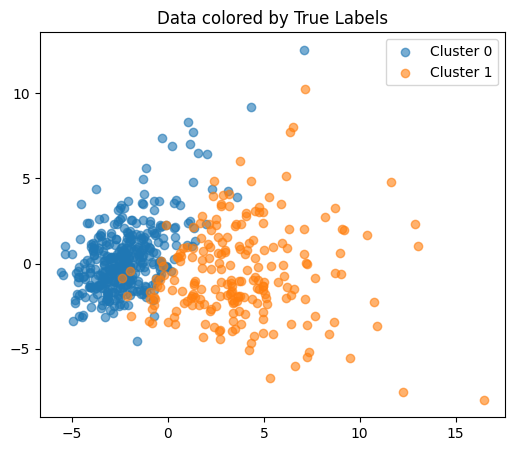

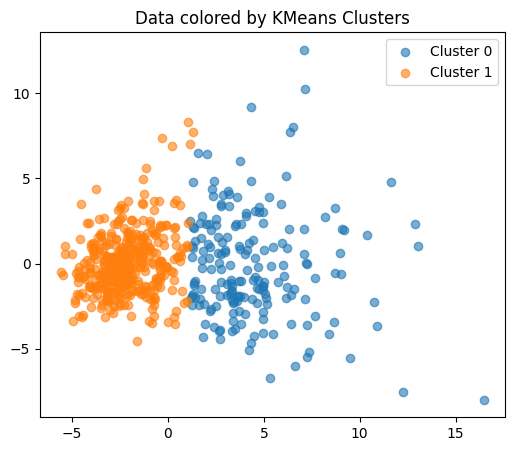

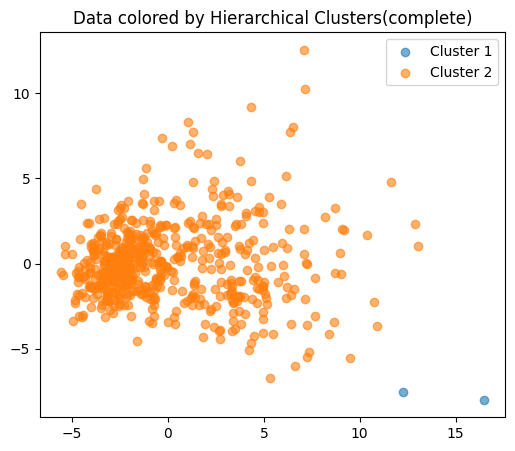

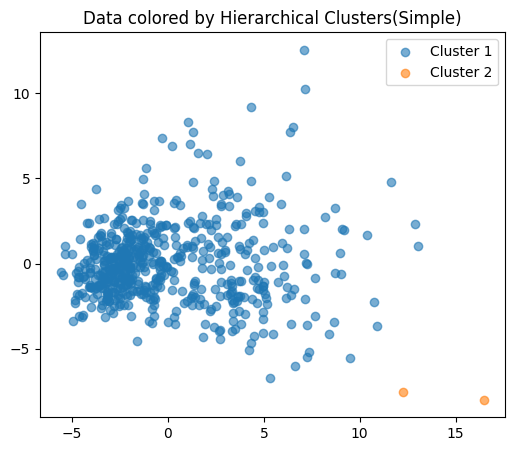

In [ ]:
pca = PCA(n_components=2)
Xa_2d = pca.fit_transform(CancerX_stand)

# Function to plot clusters
def plot_clusters(X_2d, labels, title):
    plt.figure(figsize=(6,5))
    for lab in np.unique(labels):
        plt.scatter(X_2d[labels==lab,0], X_2d[labels==lab,1], label=f'Cluster {lab}', alpha=0.6)
    plt.title(title)
    plt.legend()
    plt.show()

# Plot by true labels
plot_clusters(Xa_2d, Cancery.values, "Data colored by True Labels")

# Plot by KMeans clusters
plot_clusters(Xa_2d, kmeans_labelsC, "Data colored by KMeans Clusters")

# Plot by Hierarchical clusters(complete)
plot_clusters(Xa_2d, clustersC, "Data colored by Hierarchical Clusters(complete)")

# Plot by Hierarchical clusters(Simple)
plot_clusters(Xa_2d, clustersC2, "Data colored by Hierarchical Clusters(Simple)")

###Second Dataset

In [ ]:
# Silhouette Score (K-mean)
sil_kmeansA = silhouette_score(adultX_stand, labels_kmeansA)
print("Silhouette Score - KMeans:", sil_kmeansA)

# Silhouette Score (Hierarchical Clustering)
sil_hierA = silhouette_score(adultX_stand, clustersA)
print("Silhouette Score - Hierarchical (Complete):", sil_hierA)

# Silhouette Score (Hierarchical Clustering)
sil_hierA2 = silhouette_score(adultX_stand, clustersA2)
print("Silhouette Score - Hierarchical (Single):", sil_hierA2)

Silhouette Score - KMeans: 0.058714951049135475
Silhouette Score - Hierarchical (Complete): 0.9307286383739864
Silhouette Score - Hierarchical (Single): 0.9307286383739864


In [ ]:
#clusters vs true labels
print("\nKMeans vs True Labels:")
print(pd.crosstab(labels_kmeansA, adulty))

print("\nHierarchical vs True Labels:")
print(pd.crosstab(clustersA, adulty))

print("\nHierarchical vs True Labels:")
print(pd.crosstab(clustersA2, adulty))


KMeans vs True Labels:
income      0     1
row_0              
0        8160  6687
1       16560  1154

Hierarchical vs True Labels:
income      0     1
row_0              
1       24719  7841
2           1     0

Hierarchical vs True Labels:
income      0     1
row_0              
1       24719  7841
2           1     0


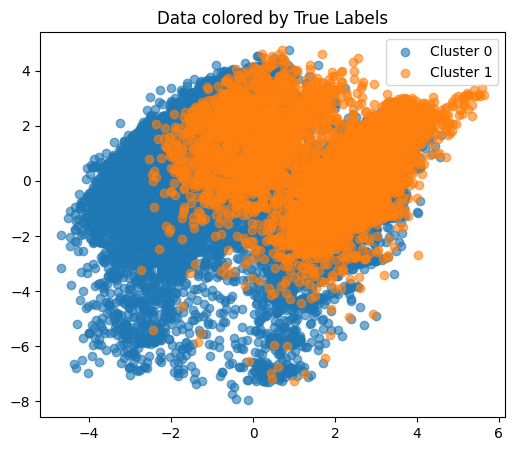

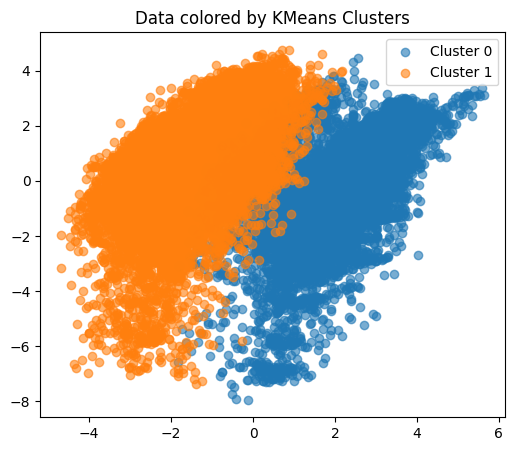

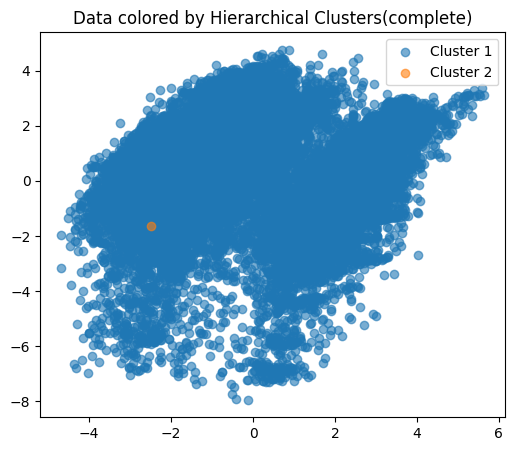

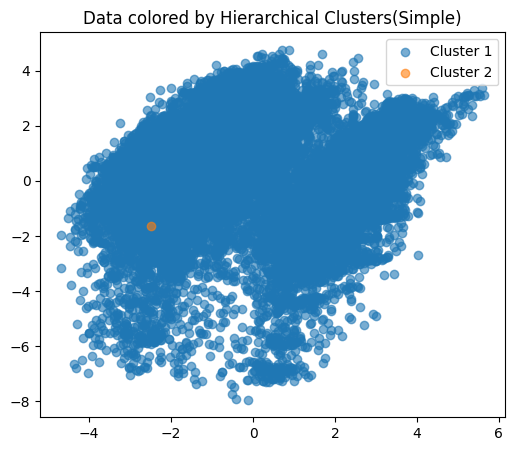

In [ ]:
pca = PCA(n_components=2)
Xa_2d = pca.fit_transform(adultX_stand)

# Function to plot clusters
def plot_clusters(X_2d, labels, title):
    plt.figure(figsize=(6,5))
    for lab in np.unique(labels):
        plt.scatter(X_2d[labels==lab,0], X_2d[labels==lab,1], label=f'Cluster {lab}', alpha=0.6)
    plt.title(title)
    plt.legend()
    plt.show()

# Plot by true labels
plot_clusters(Xa_2d, adulty.values, "Data colored by True Labels")

# Plot by KMeans clusters
plot_clusters(Xa_2d, labels_kmeansA, "Data colored by KMeans Clusters")

# Plot by Hierarchical clusters(complete)
plot_clusters(Xa_2d, clustersA, "Data colored by Hierarchical Clusters(complete)")

# Plot by Hierarchical clusters(Simple)
plot_clusters(Xa_2d, clustersA2, "Data colored by Hierarchical Clusters(Simple)")

#**Comparative** **Analysis**



1.  **How does SVM performance compare to K-Means and Hierarchical on each dataset?**


**In the first dataset**, both SVM models (Linear and RBF kernels) achieve significantly better performance, with all evaluation scores in the 90s.
K-Means does not perform well, it has a low Silhouette Score of 0.33, which is close to 0, indicating that the clusters are poorly separated and very sensitive to small changes. The clusters-vs-true-labels table also confirms weak separation.
For Hierarchical Clustering, although it achieves a higher Silhouette Score of 0.66, the cluster-vs-true-labels comparison shows that almost all data points end up in a single cluster, meaning it does not reflect the true class structure.

**In the second dataset**, both SVM models (Linear and RBF kernels) give moderate results. Accuracy is around 0.84, F1 is about 0.64, and AUC-ROC is high 0.89, but Precision and Recall are not very high.
K-Means performs very poorly, with a Silhouette Score of 0.06, which is very low. The clusters vs true labels table shows a lot of mixing, so the clusters do not represent the real classes.
Hierarchical Clustering, on the other hand, has a very high Silhouette Score 0.93, meaning the clusters are tight and well separated internally, but almost all data points end up in one cluster when compared to the true labels, so it does not match the actual classes




2. **Which method seems to separate the classes better, and why?**

**In the first dataset**, SVM separates the classes better because it uses the true labels during training and therefore learns the optimal decision boundary. This results in high ROC, accuracy, and F1 scores.
On the other hand, K-Means relies only on distance to form clusters, which is not effective for this dataset.
Although Hierarchical Clustering achieves a high Silhouette Score, this metric only measures compactness and separation within the clustering itself and does not guarantee that the clusters correspond to the true labels.

**In the second dataset**, SVM separates the classes better than K-Means because it uses the true labels to learn, which gives better results.
K-Means fails to separate the data because it only considers distances, and the clusters are heavily mixed.
Hierarchical Clustering forms very tight clusters (high Silhouette), but these clusters do not correspond to the true classes, so it cannot correctly separate the income classes.



3. **How did preprocessing (encoding, scaling) help your models?**

Preprocessing helps the models learn well, as it is a necessary step. Encoding is important because the models can’t work with categorical features. Scaling is important because all models rely on distances, so making all columns on the same scale prevents features with large values from dominating the calculations.



4. **For each dataset, which method (SVM, K-Means, Hierarchical) would you recommend, and why?**

**In the first dataset**, I recommend using SVM because it achieves the highest and most reliable performance across all evaluation metrics.
K-Means and Hierarchical Clustering may be useful for unsupervised analysis, but they do not align well with the true class labels, making them less suitable for classification in this dataset.

**In the second dataset**, I would still recommend using SVM if we want to classify the data because it gives the best match to the true labels.
K-Means is not recommended because it does not capture the class structure at all.
Hierarchical Clustering could be useful for exploring the data structure, but it cannot be used as a reliable classifier because the clusters do not align with the true labels.


